In [128]:
import pandas as pd
import seaborn as sns
import numpy as np

In [129]:
house_df = pd.read_csv("../Dataset-And-Solve-Class/class-11-Intro-ML-and-workflow/Class_11_housing_single_feature.csv")
house_df.head()

,area,price
0,7420,13300000
1,8960,12250000
2,9960,12250000
3,7500,12215000
4,7420,11410000


In [130]:
house_df.describe()

,area,price
count,545.000000,5.450000e+02
mean,5150.541284,4.766729e+06
std,2170.141023,1.870440e+06
min,1650.000000,1.750000e+06
25%,3600.000000,3.430000e+06
50%,4600.000000,4.340000e+06
75%,6360.000000,5.740000e+06
max,16200.000000,1.330000e+07


In [131]:
house_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    545 non-null    int64
 1   price   545 non-null    int64
dtypes: int64(2)
memory usage: 8.6 KB


In [132]:
""" Task: Tabular - Regression
Predict price from a given area.

estimated_price = per_sqft_price * area + registration_fee

"""
#Paramenter Initialization
per_sft_price = np.random.randint(1, 1000000)
registration_cost = np.random.randint(1, 1000000)
print(per_sft_price)
print(registration_cost)

285564
871163


In [133]:
#Define the ML Algorithm
def get_house_price(area, per_sft_price, registration_cost):
    estimated_price = per_sft_price * area + registration_cost
    return estimated_price

In [134]:
estimated_price = get_house_price(
    area = 8960,
    per_sft_price = per_sft_price,
    registration_cost = registration_cost
)

print(f"Original Price = {house_df.iloc[1]['price']}")
print(f"Estimated Price from Model = {estimated_price}")
print(f"Difference = {abs(house_df.iloc[1]['price'] - estimated_price)}")

Original Price = 12250000
Estimated Price from Model = 2559524603
Difference = 2547274603


In [135]:
#Predict the result and add to the table
house_df['estimated_price'] = [
    get_house_price(area, per_sft_price, registration_cost) for area in house_df['area']
]
house_df.head()

,area,price,estimated_price
0,7420,13300000,2119756043
1,8960,12250000,2559524603
2,9960,12250000,2845088603
3,7500,12215000,2142601163
4,7420,11410000,2119756043


In [136]:
# Add the difference feature
house_df['difference'] = abs(house_df['price'] - house_df['estimated_price'])
house_df.head()

,area,price,estimated_price,difference
0,7420,13300000,2119756043,2106456043
1,8960,12250000,2559524603,2547274603
2,9960,12250000,2845088603,2832838603
3,7500,12215000,2142601163,2130386163
4,7420,11410000,2119756043,2108346043


In [137]:
#Good, Bad result category
# house_df['prediction_type'] = house_df['difference'].apply(
#     lambda x: 'Bad' if x > 7000000000 else 'Good'
# )
house_df['prediction_type'] = np.where(house_df['difference'] > 7000000000, 'Bad', 'Good')
house_df.head()


,area,price,estimated_price,difference,prediction_type
0,7420,13300000,2119756043,2106456043,Good
1,8960,12250000,2559524603,2547274603,Good
2,9960,12250000,2845088603,2832838603,Good
3,7500,12215000,2142601163,2130386163,Good
4,7420,11410000,2119756043,2108346043,Good


In [138]:
x = []
y = []
y_type = []

for i in range(len(house_df)):
    x.append(house_df.iloc[i]["area"])
    y.append(house_df.iloc[i]["price"])
    y_type.append("y_true")
    
    x.append(house_df.iloc[i]["area"])
    y.append(house_df.iloc[i]["estimated_price"])
    y_type.append("y_pred")

house_df = pd.DataFrame({
    'area': np.array(x),
    'price': np.array(y),
    'type': np.array(y_type),
})

#improved code

# true_df = house_df[['area', 'price']].copy()
# true_df['type'] = 'y_true'

# pred_df = house_df[['area', 'estimated_price']].copy()
# pred_df = pred_df.rename(columns={'estimated_price': 'price'})
# pred_df['type'] = 'y_pred'

# house_df = pd.concat([true_df, pred_df], ignore_index=True)

print(len(house_df))
house_df.head()

1090


,area,price,type
0,7420,13300000,y_true
1,7420,2119756043,y_pred
2,8960,12250000,y_true
3,8960,2559524603,y_pred
4,9960,12250000,y_true


In [139]:
house_df.tail()

,area,price,type
1085,3620,1034612843,y_pred
1086,2910,1750000,y_true
1087,2910,831862403,y_pred
1088,3850,1750000,y_true
1089,3850,1100292563,y_pred


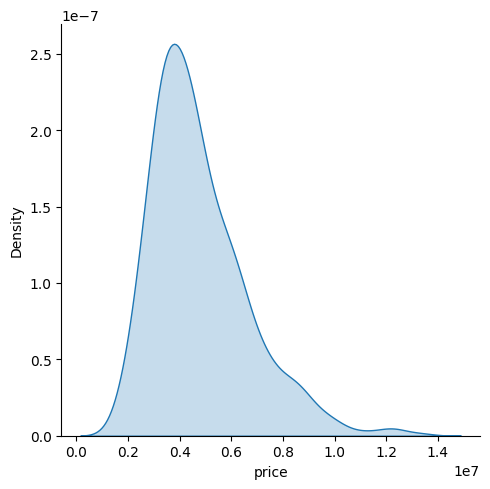

In [ ]:
sns.displot(
    data=house_df.query("type == 'y_true'"), #taking only true price
    x='price',
    kind='kde',
    fill=True
)

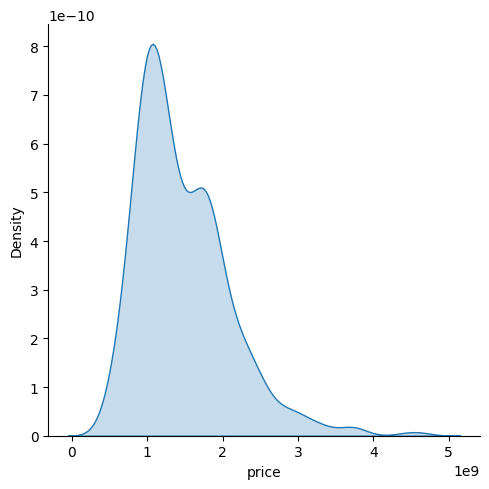

In [143]:
sns.displot(
    data=house_df.query("type == 'y_pred'"), #taking only predict price
    x='price',
    kind='kde',
    fill=True
)

In [ ]:
%pip install entropy

In [ ]:
%pip install scipy

In [148]:
from scipy.stats import entropy

"""
KL divergence: measures the dissimilarity between two distributions
  KLD = 0 : Same distribution

"""

def calculate_kl_divergence(df, epsilon=1e-10, max_divergence=1e6):
    y_pred = df[df["type"] == "y_pred"]["price"].values
    y_true = df[df["type"] == "y_true"]["price"].values
    
    y_pred_prob = y_pred / np.sum(y_pred)
    y_true_prob = y_true / np.sum(y_true)
    
    y_pred_prob = np.clip(y_pred_prob, epsilon, 1)
    y_true_prob = np.clip(y_true_prob, epsilon, 1)
    
    kl_div = entropy(y_true_prob, y_pred_prob)
    
    if np.isinf(kl_div):
        kl_div = max_divergence
    
    return kl_div

kl_divergence = calculate_kl_divergence(house_df)
print(f"KL Divergence: {kl_divergence}")

KL Divergence: 0.06379196959068925
